In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('husl')

In [3]:
df = pd.read_csv('../data/country_panel.csv')

In [4]:
print(f'Shape: {df.shape}')
print(f'Countries: {df.country_code.nunique()}')
print(f'Years: {df.year.min()} – {df.year.max()}')
print(f'\nColumns:\n{df.columns.tolist()}')

Shape: (7328, 28)
Countries: 229
Years: 1990 – 2021

Columns:
['country_name', 'country_code', 'year', 'gdp_per_capita', 'inflation', 'unemployment', 'trade_pct_gdp', 'govt_expenditure', 'urban_pop_pct', 'internet_users', 'private_credit_gdp', 'bank_assets_gdp', 'liquid_liabilities_gdp', 'bank_zscore', 'bank_npl', 'bank_capital_ratio', 'net_interest_margin', 'bank_roa', 'bank_roe', 'bank_deposits_gdp', 'life_expectancy', 'child_mortality', 'fertility_rate', 'clean_water_access', 'primary_enrollment', 'secondary_enrollment', 'edu_expenditure', 'literacy_rate']


In [5]:
# First 5 rows — see what the data actually looks like
print('=== FIRST 5 ROWS ===')
display(df.head())

# Basic statistics for every numeric column
print('\n=== BASIC STATISTICS ===')
display(df.describe().round(2))

=== FIRST 5 ROWS ===


,country_name,country_code,year,gdp_per_capita,inflation,unemployment,trade_pct_gdp,govt_expenditure,urban_pop_pct,internet_users,...,bank_roe,bank_deposits_gdp,life_expectancy,child_mortality,fertility_rate,clean_water_access,primary_enrollment,secondary_enrollment,edu_expenditure,literacy_rate
0,Aruba,ABW,1990,12187.536361,5.836688,NaN,NaN,NaN,65.432816,0.0,...,NaN,49.63587,72.546,NaN,2.345,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1991,13233.990517,5.555556,NaN,NaN,NaN,65.400922,NaN,...,NaN,51.45119,72.592,NaN,2.362,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1992,13892.605143,3.873375,NaN,NaN,NaN,65.390589,NaN,...,NaN,53.37284,72.717,NaN,2.353,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,1993,14700.959808,5.215560,NaN,NaN,NaN,65.384467,NaN,...,NaN,49.85363,72.777,NaN,2.331,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,1994,16055.287787,6.311080,NaN,NaN,NaN,65.380048,NaN,...,NaN,49.58435,72.796,NaN,2.298,NaN,NaN,NaN,NaN,NaN



=== BASIC STATISTICS ===


,year,gdp_per_capita,inflation,unemployment,trade_pct_gdp,govt_expenditure,urban_pop_pct,internet_users,private_credit_gdp,bank_assets_gdp,...,bank_roe,bank_deposits_gdp,life_expectancy,child_mortality,fertility_rate,clean_water_access,primary_enrollment,secondary_enrollment,edu_expenditure,literacy_rate
count,7328.00,6986.00,5861.00,6169.00,5700.00,3597.00,7328.00,5751.00,5378.00,5407.00,...,3215.00,5314.00,7328.00,6656.00,7328.00,3314.00,4997.00,4246.00,2895.00,1123.00
mean,2005.50,12514.85,24.00,8.10,84.11,26.71,56.59,28.00,43.74,54.18,...,12.64,49.33,68.92,48.65,3.09,65.92,100.61,75.04,4.41,79.92
std,9.23,21107.22,358.72,5.97,54.61,20.36,24.18,30.53,38.39,43.49,...,12.67,45.64,9.46,52.75,1.63,31.29,16.61,30.58,1.97,18.84
min,1990.00,22.95,-16.86,0.10,0.02,0.00,5.27,0.00,0.02,0.04,...,-117.67,0.04,12.16,1.50,0.76,1.28,20.88,5.22,0.00,10.89
25%,1997.75,1071.80,1.81,3.85,50.47,17.04,36.22,1.32,15.10,20.79,...,7.62,19.94,63.26,11.20,1.77,40.75,96.82,51.58,3.14,69.23
50%,2005.50,3702.58,3.94,6.36,71.98,25.13,55.90,14.51,32.41,43.25,...,12.19,39.43,70.90,27.05,2.58,74.62,102.13,82.22,4.22,86.10
75%,2013.25,15240.47,8.19,10.78,102.39,34.04,76.02,52.50,59.49,74.00,...,17.69,63.68,75.96,69.90,4.19,96.34,108.66,97.19,5.41,94.53
max,2021.00,223823.36,23773.13,38.80,863.20,758.96,100.00,100.00,304.57,305.24,...,259.01,462.13,86.15,478.90,8.61,100.00,165.65,163.93,44.33,100.00


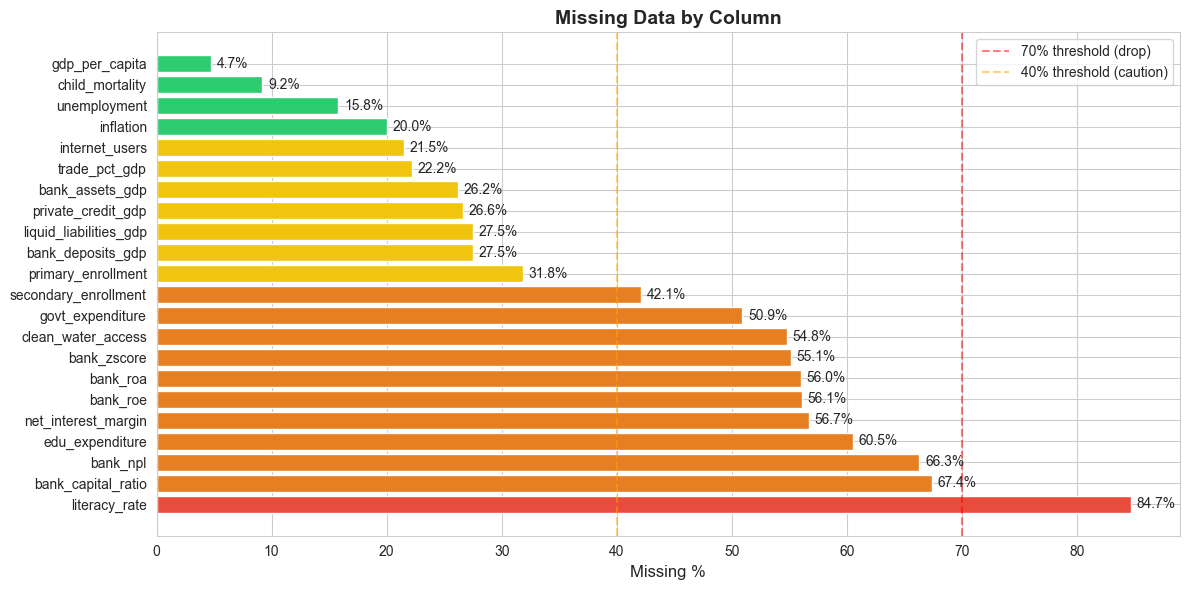

literacy_rate             84.7
bank_capital_ratio        67.4
bank_npl                  66.3
edu_expenditure           60.5
net_interest_margin       56.7
bank_roe                  56.1
bank_roa                  56.0
bank_zscore               55.1
clean_water_access        54.8
govt_expenditure          50.9
secondary_enrollment      42.1
primary_enrollment        31.8
bank_deposits_gdp         27.5
liquid_liabilities_gdp    27.5
private_credit_gdp        26.6
bank_assets_gdp           26.2
trade_pct_gdp             22.2
internet_users            21.5
inflation                 20.0
unemployment              15.8
child_mortality            9.2
gdp_per_capita             4.7
dtype: float64


In [ ]:
# === MISSING VALUES ANALYSIS ===

# Calculate missing % per column
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(missing.index, missing.values, color=[
    "#e74c3c" if x > 70 else '#e67e22' if x > 40 else '#f1c40f' if x > 20 else '#2ecc71'
    for x in missing.values
])

# Add percentage labels on bars
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)

ax.set_xlabel('Missing %', fontsize=12)
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
ax.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='70% threshold (drop)')
ax.axvline(x=40, color='orange', linestyle='--', alpha=0.5, label='40% threshold (caution)')
ax.legend()
plt.tight_layout()
plt.show()

print(missing)

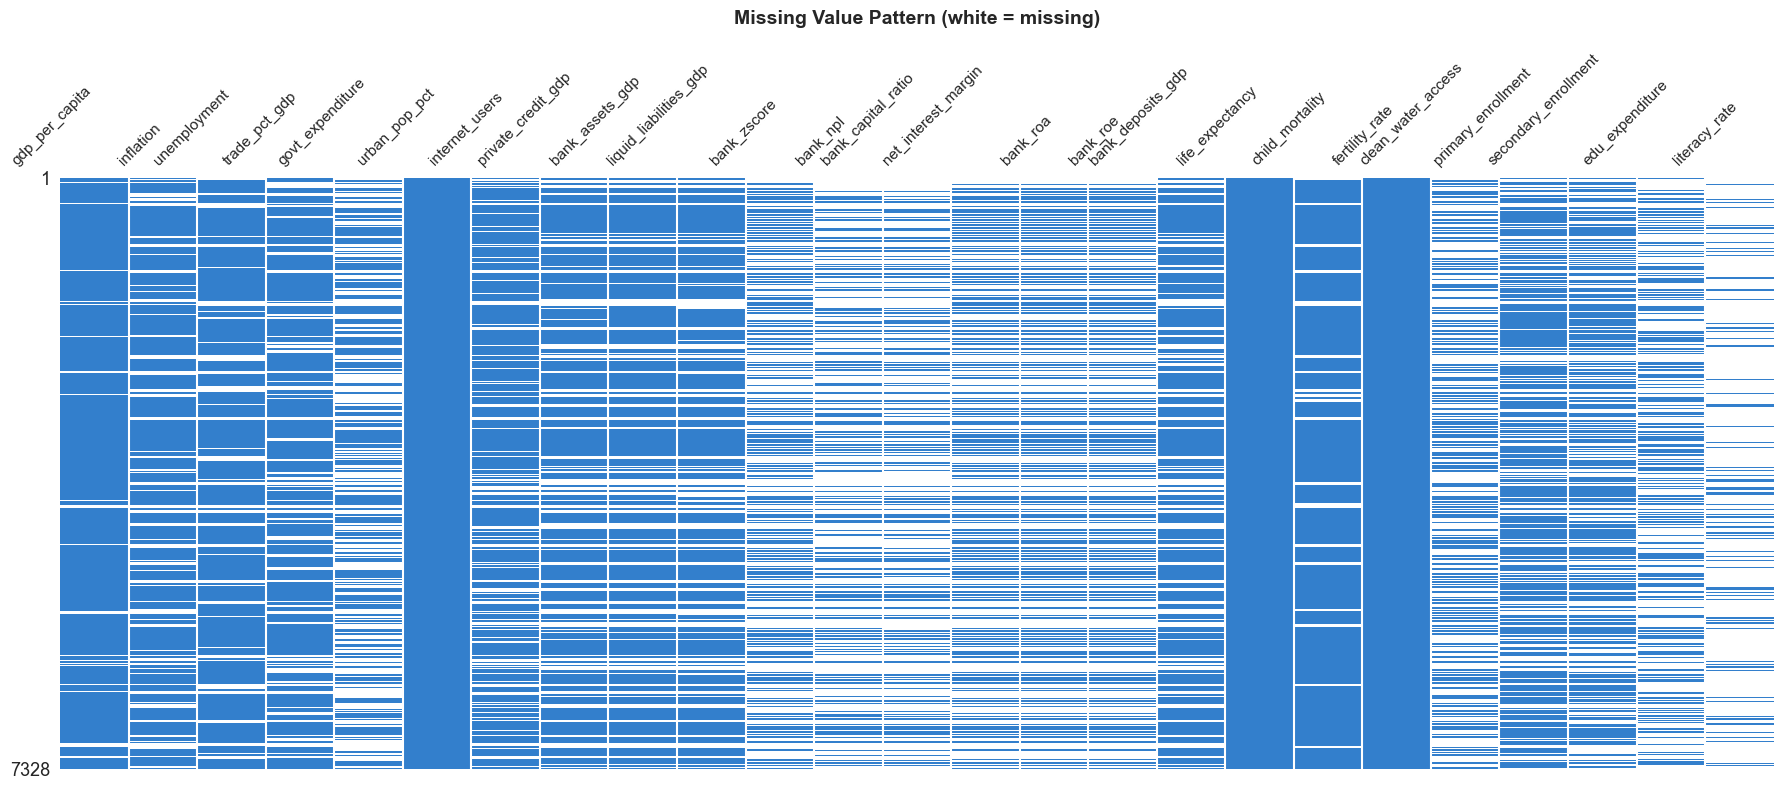

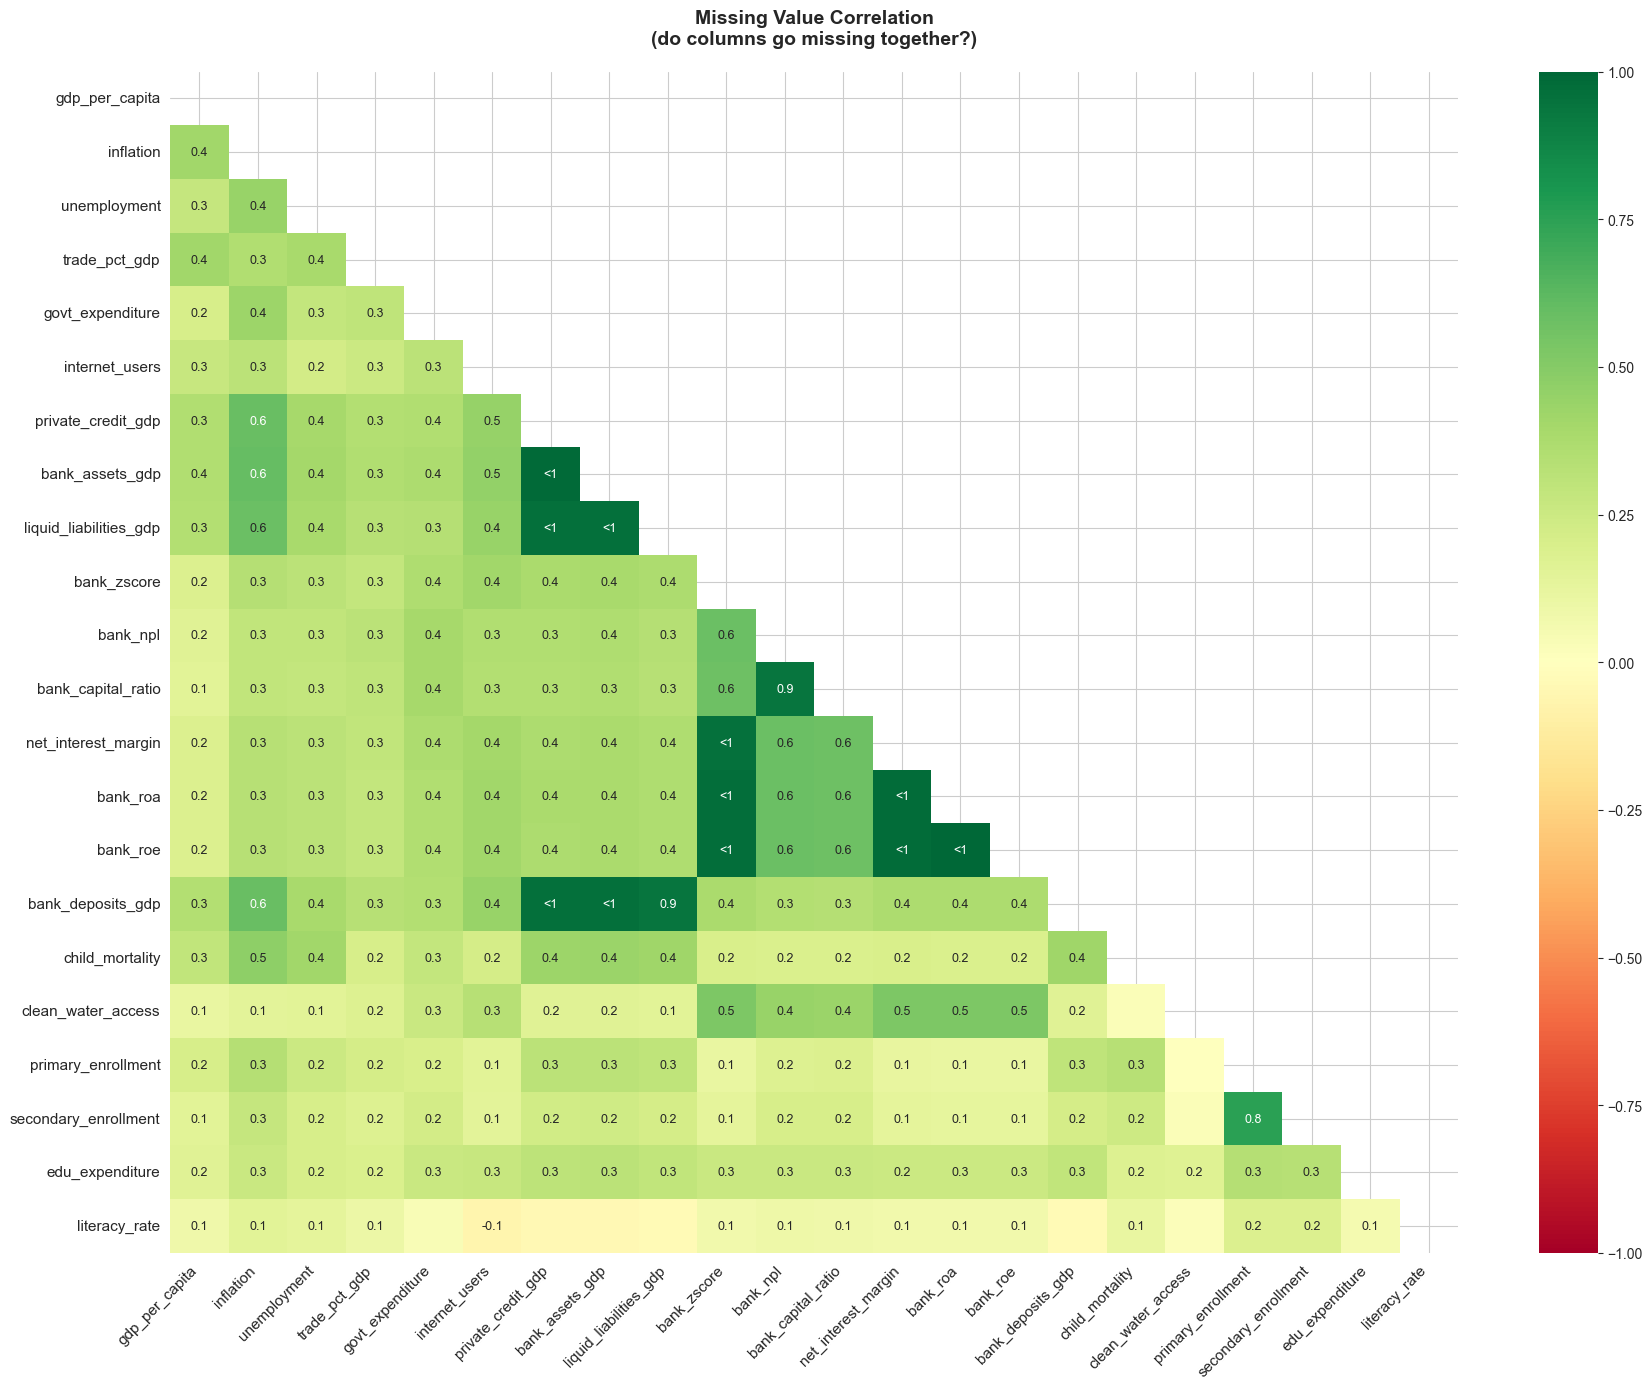

In [12]:
# === MISSING VALUE PATTERN (improved) ===

# Chart 1: Missingness matrix — bigger and cleaner
fig, ax = plt.subplots(figsize=(18, 8))
msno.matrix(df.drop(columns=['country_name', 'country_code', 'year']),
            ax=ax,
            sparkline=False,
            color=(0.2, 0.5, 0.8),
            fontsize=11)
ax.set_title('Missing Value Pattern (white = missing)', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Chart 2: Missingness correlation heatmap — separate plot
fig, ax = plt.subplots(figsize=(18, 14))
msno.heatmap(df.drop(columns=['country_name', 'country_code', 'year']),
             ax=ax,
             cmap='RdYlGn',
             fontsize=11)
ax.set_title('Missing Value Correlation\n(do columns go missing together?)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

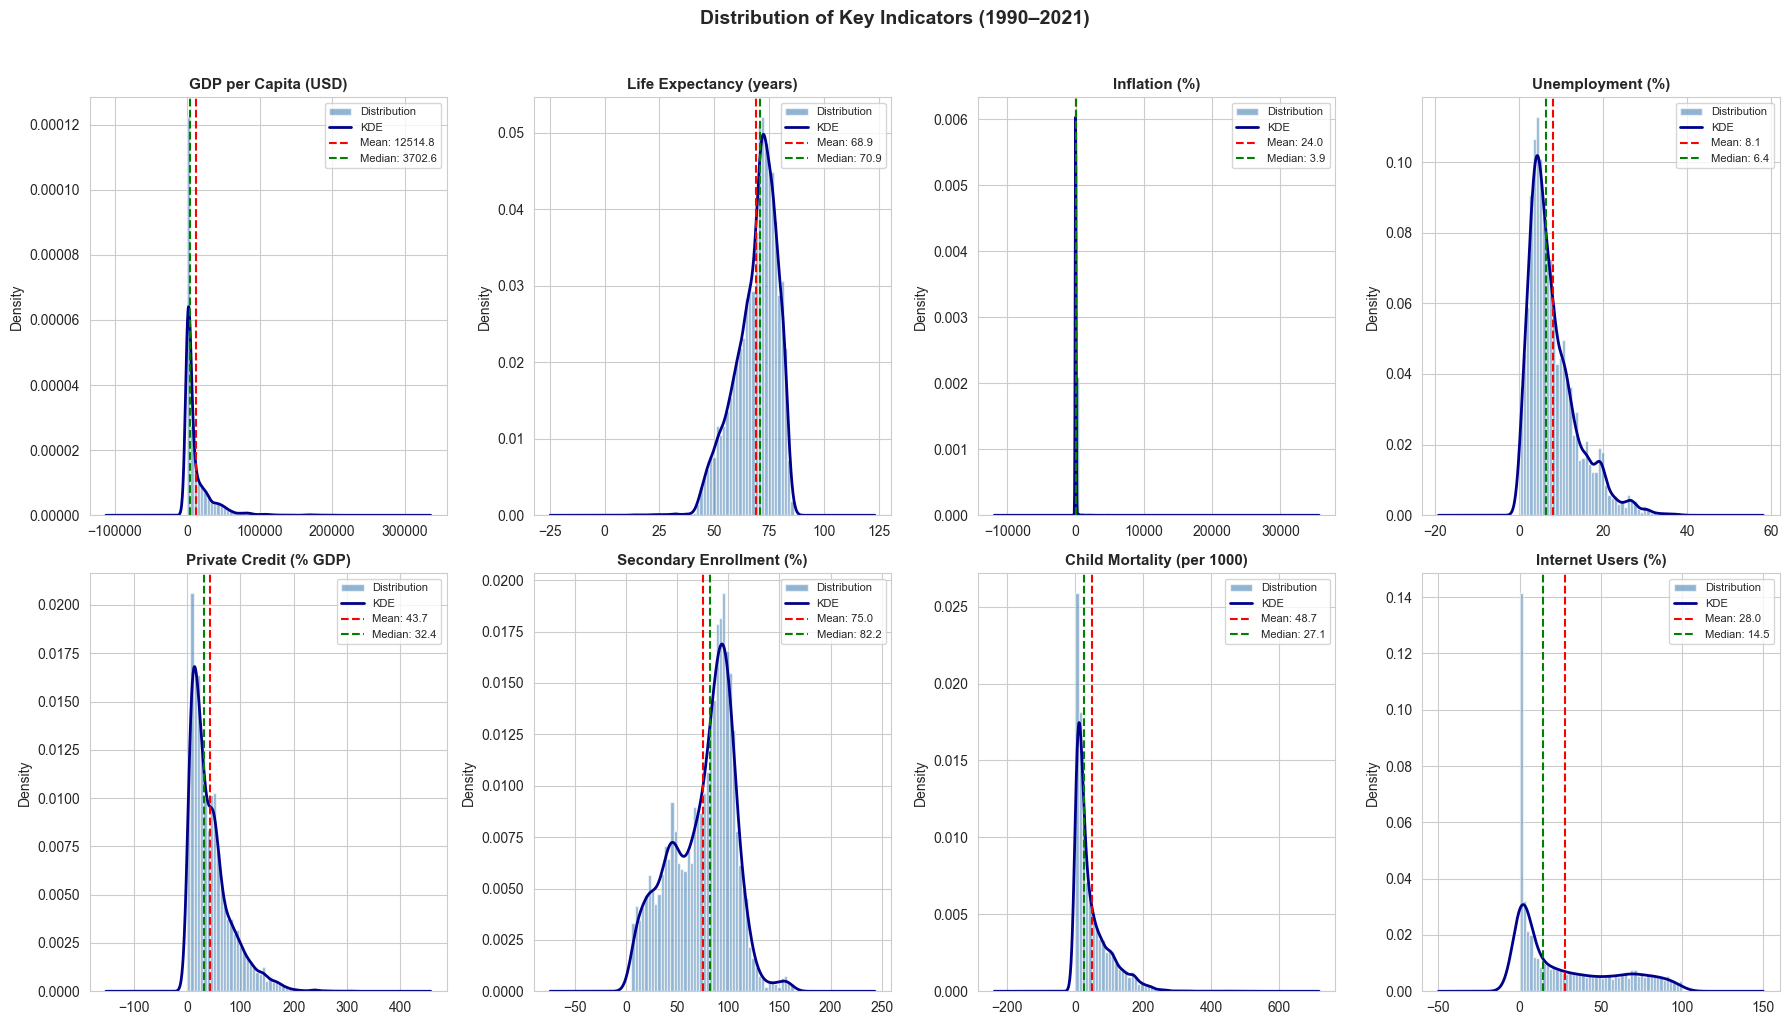

In [13]:
# === DISTRIBUTIONS OF KEY INDICATORS ===
# Understanding the shape of each variable before modeling

indicators = {
    'gdp_per_capita':       'GDP per Capita (USD)',
    'life_expectancy':      'Life Expectancy (years)',
    'inflation':            'Inflation (%)',
    'unemployment':         'Unemployment (%)',
    'private_credit_gdp':   'Private Credit (% GDP)',
    'secondary_enrollment': 'Secondary Enrollment (%)',
    'child_mortality':      'Child Mortality (per 1000)',
    'internet_users':       'Internet Users (%)',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(indicators.items()):
    data = df[col].dropna()

    # Histogram + KDE curve
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.6, density=True, label='Distribution')
    data.plot.kde(ax=axes[i], color='darkblue', linewidth=2, label='KDE')

    # Add mean and median lines
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='green',  linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')

    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution of Key Indicators (1990–2021)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

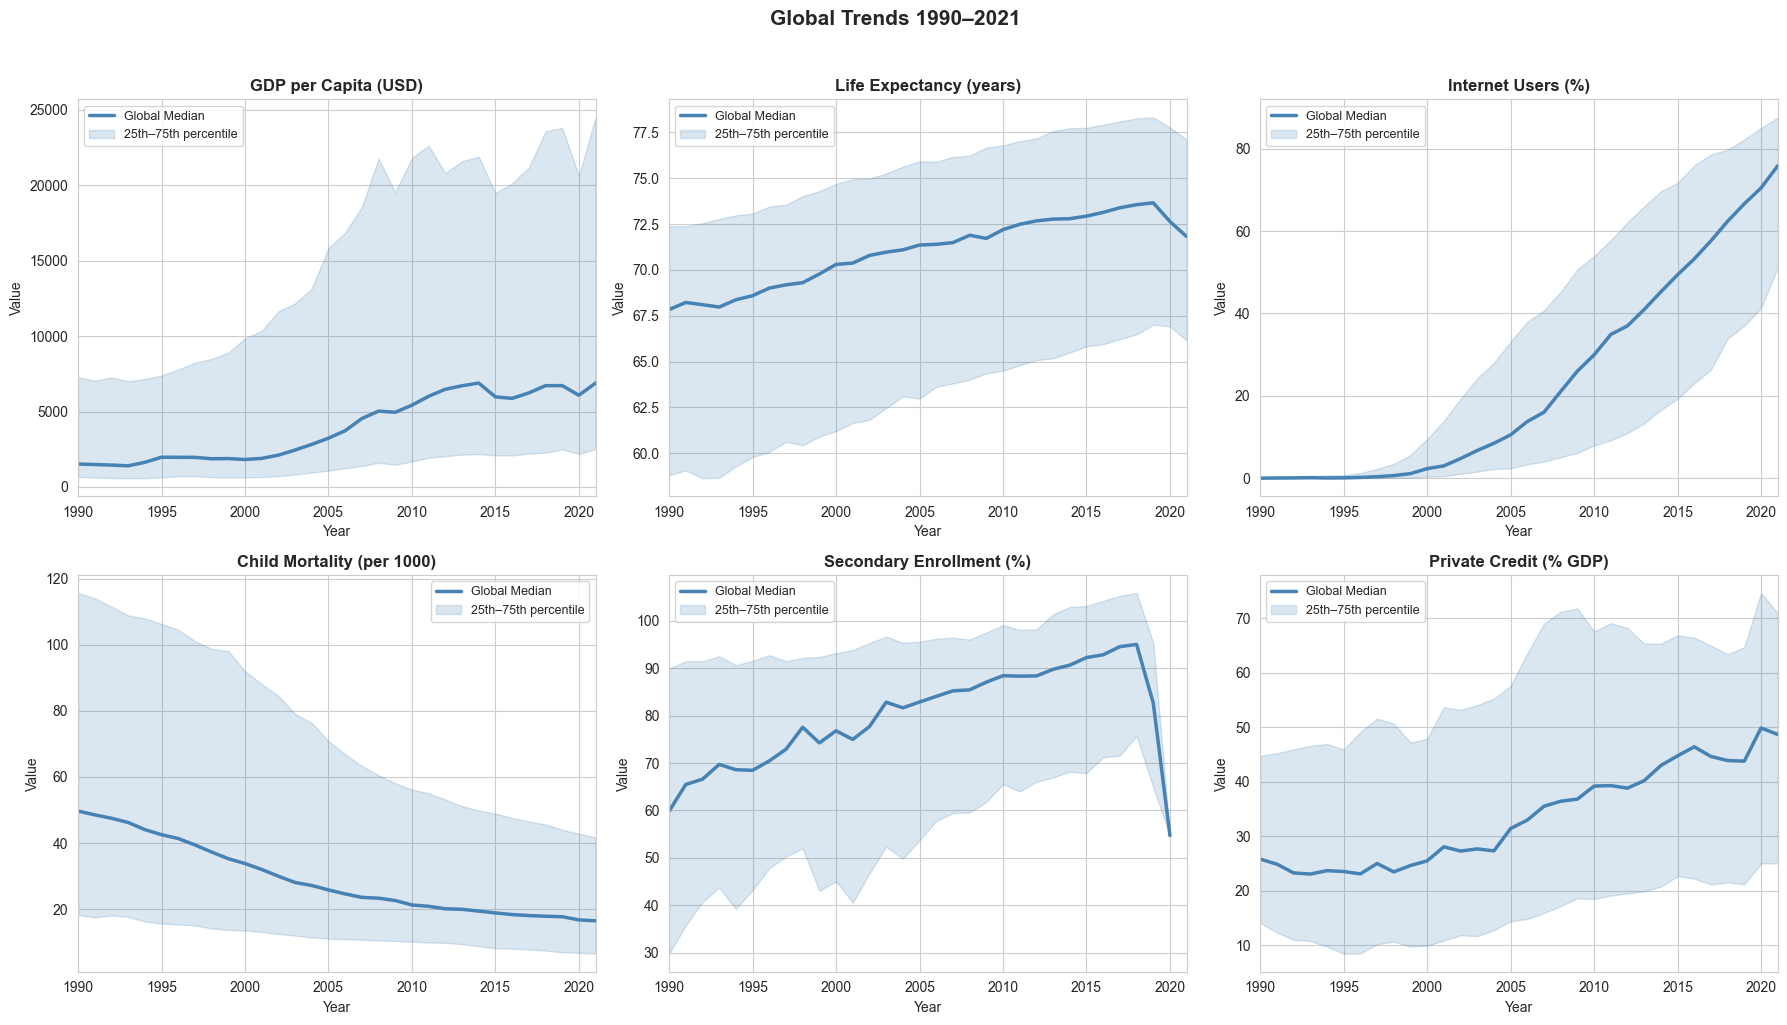

In [14]:
# === TRENDS OVER TIME ===
# How have key indicators changed globally from 1990 to 2021?

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

trend_cols = {
    'gdp_per_capita':      'GDP per Capita (USD)',
    'life_expectancy':     'Life Expectancy (years)',
    'internet_users':      'Internet Users (%)',
    'child_mortality':     'Child Mortality (per 1000)',
    'secondary_enrollment':'Secondary Enrollment (%)',
    'private_credit_gdp':  'Private Credit (% GDP)',
}

for i, (col, title) in enumerate(trend_cols.items()):
    # Global median per year
    yearly = df.groupby('year')[col].median()
    yearly_25 = df.groupby('year')[col].quantile(0.25)
    yearly_75 = df.groupby('year')[col].quantile(0.75)

    axes[i].plot(yearly.index, yearly.values, 
                 color='steelblue', linewidth=2.5, label='Global Median')
    
    # Shaded band between 25th and 75th percentile
    axes[i].fill_between(yearly.index, yearly_25, yearly_75,
                         alpha=0.2, color='steelblue', label='25th–75th percentile')
    
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(1990, 2021)

plt.suptitle('Global Trends 1990–2021', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

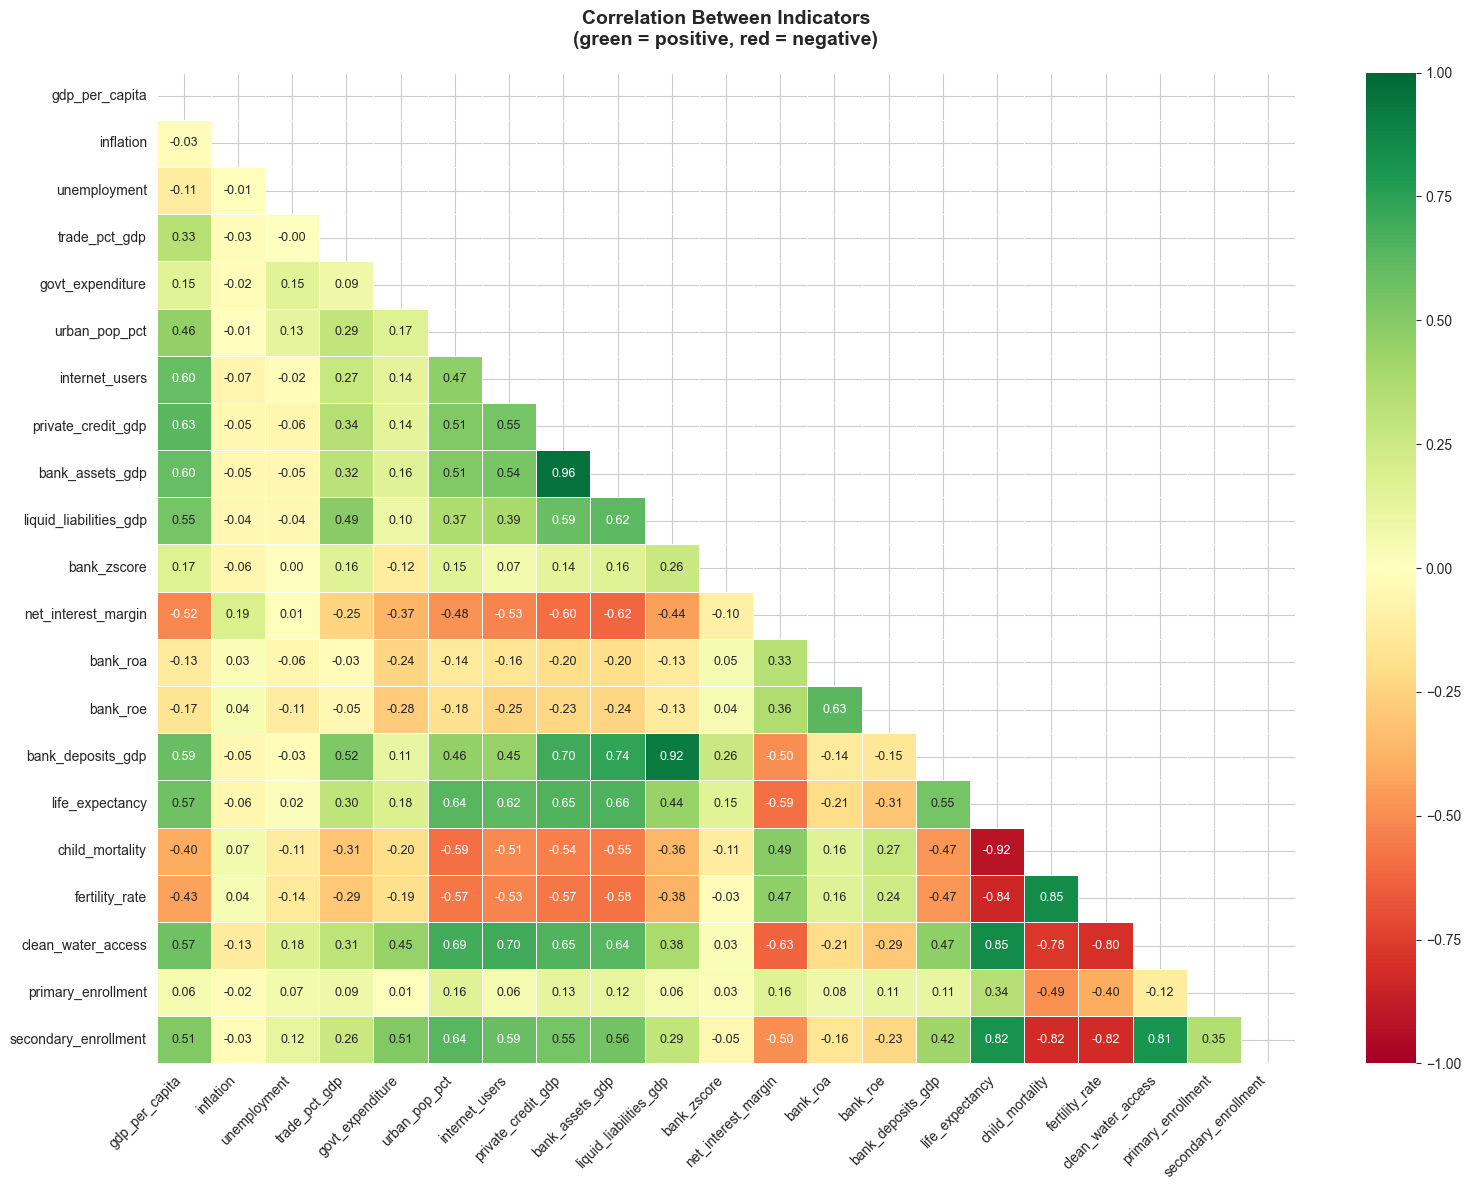

In [15]:
# === CORRELATION HEATMAP ===
# How strongly are our indicators related to each other?

# Select numeric columns with less than 60% missing
good_cols = [col for col in df.select_dtypes(include=np.number).columns
             if df[col].isnull().mean() < 0.60
             and col != 'year']

# Calculate correlation matrix
corr_matrix = df[good_cols].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Between Indicators\n(green = positive, red = negative)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

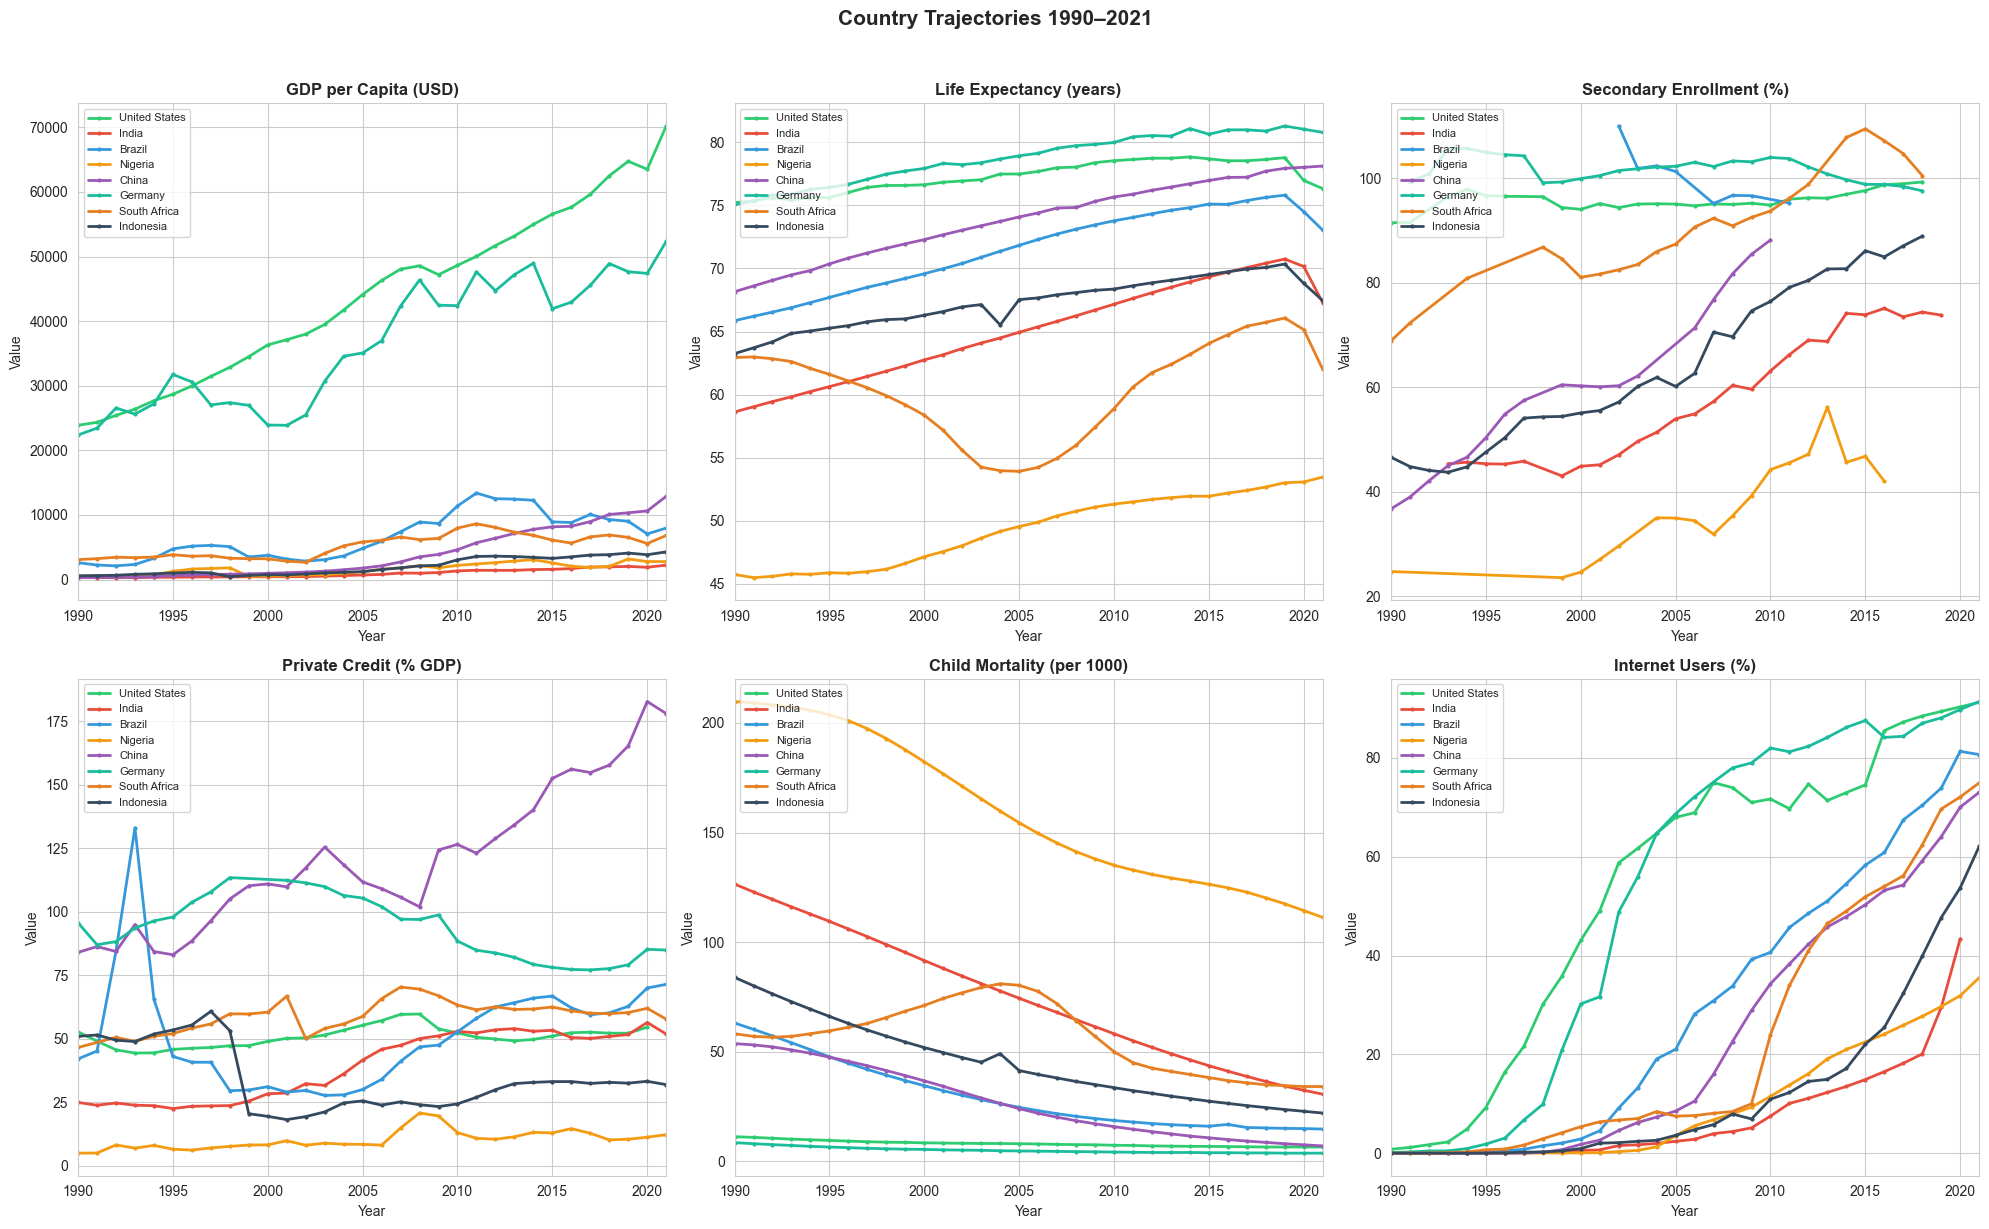

In [16]:
# === COUNTRY SPOTLIGHTS ===
# Compare trajectories of selected countries across key indicators

# Pick a diverse set of countries representing different development levels
countries = {
    'USA':  'United States',
    'IND':  'India',
    'BRA':  'Brazil',
    'NGA':  'Nigeria',
    'CHN':  'China',
    'DEU':  'Germany',
    'ZAF':  'South Africa',
    'IDN':  'Indonesia',
}

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', 
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

spotlight_cols = {
    'gdp_per_capita':       'GDP per Capita (USD)',
    'life_expectancy':      'Life Expectancy (years)',
    'secondary_enrollment': 'Secondary Enrollment (%)',
    'private_credit_gdp':   'Private Credit (% GDP)',
    'child_mortality':      'Child Mortality (per 1000)',
    'internet_users':       'Internet Users (%)',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(spotlight_cols.items()):
    for j, (code, name) in enumerate(countries.items()):
        country_df = df[df['country_code'] == code][['year', col]].dropna()
        if len(country_df) > 0:
            axes[i].plot(country_df['year'], country_df[col],
                        color=colors[j], linewidth=2,
                        label=name, marker='o', markersize=2)

    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].legend(fontsize=8, loc='upper left')
    axes[i].set_xlim(1990, 2021)

plt.suptitle('Country Trajectories 1990–2021', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()